# Setup

In [65]:
# !pip install python-terrier pandas pyarrow
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from tqdm import tqdm

stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from bertopic import BERTopic
from umap import UMAP

print("imports ready")

# os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/temurin-25.jdk/Contents/Home"
# os.environ["JVM_PATH"]  = "/Library/Java/JavaVirtualMachines/temurin-25.jdk/Contents/Home/lib/server/libjvm.dylib"

os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/jdk-25.jdk/Contents/Home"
os.environ["JVM_PATH"] = "/Library/Java/JavaVirtualMachines/jdk-25.jdk/Contents/Home/lib/server/libjvm.dylib"
os.environ["PATH"]      = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

import pyterrier as pt
if not pt.java.started():
    pt.java.init()

print("pyterrier ready")

imports ready
pyterrier ready


# Preprocessing

### Config

In [66]:
DATA_DIR = Path("../data/raw")
OUTPUT   = Path("../data/corpus.parquet")

print(f"data dir : {DATA_DIR}")
print(f"output   : {OUTPUT}")

data dir : ../data/raw
output   : ../data/corpus.parquet


### Path Parser

The file path encodes all the metadata we need — newspaper ID, date, edition, page.

In [67]:
# sn########/YYYY/MM/DD/ed-#/seq-#/ocr.txt
PATH_RE = re.compile(r"(sn\d+)/(\d{4})/(\d{2})/(\d{2})/ed-(\d+)/seq-(\d+)/ocr\.txt")

def parse_path(path):
    match = PATH_RE.search(path.as_posix())
    if not match:
        return None
    lccn, year, month, day, edition, page = match.groups()
    return {
        "doc_id"  : f"{lccn}_{year}_{month}_{day}_ed{edition}_seq{page}",
        "lccn"    : lccn,
        "date"    : f"{year}-{month}-{day}",
        "edition" : int(edition),
        "page"    : int(page),
    }

# sanity check
print(parse_path(Path("sn84020235/1906/03/03/ed-1/seq-7/ocr.txt")))

{'doc_id': 'sn84020235_1906_03_03_ed1_seq7', 'lccn': 'sn84020235', 'date': '1906-03-03', 'edition': 1, 'page': 7}


### Preprocessing

In [68]:
def clean_text(text):
    lowercased = text.lower()
    all_words = re.findall(r'[a-z]{3,}', lowercased)
    without_stops = [w for w in all_words if w not in stop_words]
    stemmed = [stemmer.stem(w) for w in without_stops]
    return " ".join(stemmed)

# sanity check
raw = "The quick brown fox jumps over the lazy dog. l8o6 ||| OCR garbage!!! TWENTY-THIRD YEAR."
print("RAW    :", raw)
print("CLEANED:", clean_text(raw))

RAW    : The quick brown fox jumps over the lazy dog. l8o6 ||| OCR garbage!!! TWENTY-THIRD YEAR.
CLEANED: quick brown fox jump lazi dog ocr garbag twenti third year


### Load Corpus

In [69]:
ocr_files = sorted(DATA_DIR.rglob("ocr.txt"))
print(f"found {len(ocr_files)} ocr.txt files")

found 608 ocr.txt files


In [70]:
records = []
skipped = 0

for path in tqdm(ocr_files, desc="ingesting"):
    meta = parse_path(path)
    if meta is None:
        skipped += 1
        continue

    raw_text = path.read_text(encoding="utf-8", errors="replace")
    cleaned = clean_text(raw_text)
    token_count = len(cleaned.split())

    records.append({
        "doc_id"      : meta["doc_id"],
        "lccn"        : meta["lccn"],
        "date"        : meta["date"],
        "edition"     : meta["edition"],
        "page"        : meta["page"],
        "raw_text"    : raw_text,
        "clean_text"  : cleaned,
        "token_count" : token_count,
    })

print(f"loaded  : {len(records)}")
print(f"skipped : {skipped}")

ingesting: 100%|██████████| 608/608 [00:06<00:00, 94.77it/s] 

loaded  : 608
skipped : 0


### Corpus Stats

In [71]:
df = pd.DataFrame(records)
df["date"] = pd.to_datetime(df["date"])

print(df.shape)
print(f"date range        : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"unique newspapers : {df['lccn'].nunique()}")
print(f"avg tokens/page   : {df['token_count'].mean():.0f}")
print()
df[["doc_id", "date", "lccn", "page", "token_count"]].head(10)

(608, 8)
date range        : 1906-01-06 -> 1906-12-29
unique newspapers : 2
avg tokens/page   : 2158



,doc_id,date,lccn,page,token_count
0,sn83035387_1906_01_06_ed1_seq1,1906-01-06,sn83035387,1,3239
1,sn83035387_1906_01_06_ed1_seq2,1906-01-06,sn83035387,2,3700
2,sn83035387_1906_01_06_ed1_seq3,1906-01-06,sn83035387,3,2568
3,sn83035387_1906_01_06_ed1_seq4,1906-01-06,sn83035387,4,2696
4,sn83035387_1906_01_13_ed1_seq1,1906-01-13,sn83035387,1,3260
5,sn83035387_1906_01_13_ed1_seq2,1906-01-13,sn83035387,2,3677
6,sn83035387_1906_01_13_ed1_seq3,1906-01-13,sn83035387,3,2485
7,sn83035387_1906_01_13_ed1_seq4,1906-01-13,sn83035387,4,3249
8,sn83035387_1906_01_20_ed1_seq1,1906-01-20,sn83035387,1,3386
9,sn83035387_1906_01_20_ed1_seq2,1906-01-20,sn83035387,2,3415


In [72]:
# token count before and after preprocessing
df['raw_len'] = df['raw_text'].str.split().apply(len)
df['clean_len'] = df['clean_text'].str.split().apply(len)

print(f"avg raw tokens   : {df['raw_len'].mean():.0f}")
print(f"avg clean tokens : {df['clean_len'].mean():.0f}")
print(f"reduction        : {100 * (1 - df['clean_len'].mean() / df['raw_len'].mean()):.1f}%")
print()
print(df[['raw_len', 'clean_len']].describe().round(2))

avg raw tokens   : 4033
avg clean tokens : 2158
reduction        : 46.5%

       raw_len  clean_len
count   608.00     608.00
mean   4032.55    2157.50
std    1283.29     713.89
min    1352.00     712.00
25%    2959.00    1559.50
50%    3921.00    2053.00
75%    5012.25    2707.50
max    7251.00    3930.00


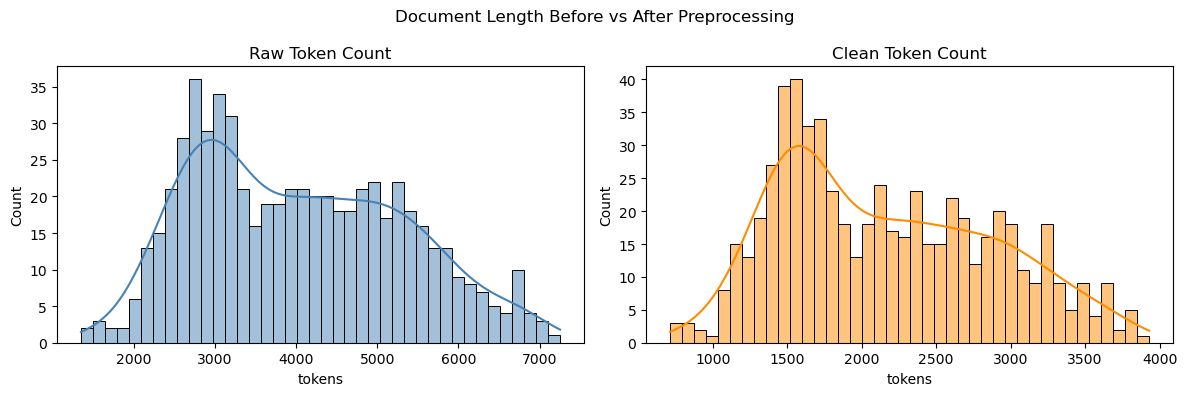

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['raw_len'],   bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Raw Token Count")
axes[0].set_xlabel("tokens")

sns.histplot(df['clean_len'], bins=40, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title("Clean Token Count")
axes[1].set_xlabel("tokens")

plt.suptitle("Document Length Before vs After Preprocessing")
plt.tight_layout()
plt.show()

### Vocabulary Analysis

In [74]:
flat_tokens   = [t for text in df['clean_text'] for t in text.split()]
vocab_counter = Counter(flat_tokens)

print(f"total tokens  : {len(flat_tokens):,}")
print(f"unique tokens : {len(vocab_counter):,}")
print(f"TTR           : {len(vocab_counter) / len(flat_tokens):.4f}")

total tokens  : 1,311,763
unique tokens : 55,366
TTR           : 0.0422


In [75]:
# top 25 terms after preprocessing
pd.DataFrame(vocab_counter.most_common(25), columns=["term", "frequency"])

,term,frequency
0,mr,12477
1,one,6976
2,street,6506
3,year,5241
4,day,4636
5,citi,4544
6,loui,4486
7,new,4389
8,state,4088
9,miss,4052


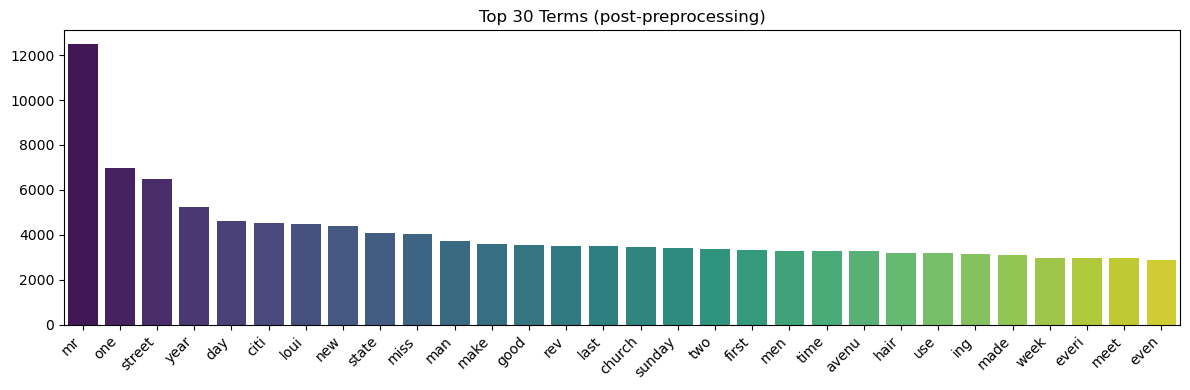

In [76]:
# top 30 bar chart
terms, freqs = zip(*vocab_counter.most_common(30))
plt.figure(figsize=(12, 4))
sns.barplot(x=list(terms), y=list(freqs), palette="viridis")
plt.title("Top 30 Terms (post-preprocessing)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Save

In [77]:
df.drop(columns=["raw_len", "clean_len"]).to_parquet(OUTPUT, index=False)
print(f"saved -> {OUTPUT}  ({OUTPUT.stat().st_size / 1024:.1f} KB)")

saved -> ../data/corpus.parquet  (14388.7 KB)


# Indexing

### Config

In [78]:
CORPUS     = Path("../data/corpus.parquet")
INDEX_PATH = "../data/pt_index"

os.makedirs(INDEX_PATH, exist_ok=True)

### Load Corpus

In [79]:
df = pd.read_parquet(CORPUS)
print(f"loaded {len(df)} documents")
df[["doc_id", "date", "token_count"]].head(5)

loaded 608 documents


,doc_id,date,token_count
0,sn83035387_1906_01_06_ed1_seq1,1906-01-06,3239
1,sn83035387_1906_01_06_ed1_seq2,1906-01-06,3700
2,sn83035387_1906_01_06_ed1_seq3,1906-01-06,2568
3,sn83035387_1906_01_06_ed1_seq4,1906-01-06,2696
4,sn83035387_1906_01_13_ed1_seq1,1906-01-13,3260


### Build Inverted Index

In [80]:
# pyterrier expects 'docno' and 'text' columns
corpus_pt = df[["doc_id", "clean_text"]].rename(columns={"doc_id": "docno", "clean_text": "text"}).copy()
corpus_pt["docno"] = corpus_pt["docno"].astype(str)

indexer = pt.IterDictIndexer(INDEX_PATH, overwrite=True, meta={"docno": 50, "text": 25000})
index_ref = indexer.index(corpus_pt.to_dict(orient="records"))

print("index created:", index_ref)

index created: <org.terrier.querying.IndexRef at 0x16acc9b80 jclass=org/terrier/querying/IndexRef jself=<LocalRef obj=0x14f898ce2 at 0x3d92dbfb0>>


In [81]:
index = pt.IndexFactory.of(index_ref)
stats = index.getCollectionStatistics()

print(f"documents    : {stats.getNumberOfDocuments()}")
print(f"unique terms : {stats.getNumberOfUniqueTerms():,}")
print(f"avg doc len  : {stats.getAverageDocumentLength():.2f}")

documents    : 608
unique terms : 54,172
avg doc len  : 2029.62


In [82]:
# show which documents contain a term -- demonstrates the inverted index directly
def show_postings(term, top_n=5):
    entry = index.getLexicon().getLexiconEntry(term)
    if entry is None:
        print(f"'{term}' not found")
        return
    postings = index.getInvertedIndex().getPostings(entry)
    print(f"'{term}' appears in {entry.getDocumentFrequency()} documents, showing first {top_n}:")
    for i, posting in enumerate(postings):
        if i >= top_n:
            break
        doc_id = df.iloc[posting.getId()]["doc_id"]
        print(f"  {doc_id}  (tf={posting.getFrequency()})")

show_postings("earthquak")

'earthquak' appears in 39 documents, showing first 5:
  sn83035387_1906_01_06_ed1_seq2  (tf=1)
  sn83035387_1906_03_17_ed1_seq2  (tf=1)
  sn83035387_1906_03_24_ed1_seq4  (tf=2)
  sn83035387_1906_04_21_ed1_seq4  (tf=8)
  sn83035387_1906_04_28_ed1_seq2  (tf=5)


### Postings List Inspection

In [83]:
def term_info(term):
    entry = index.getLexicon().getLexiconEntry(term)
    if entry is not None:
        print(f"'{term}' -> DF={entry.getDocumentFrequency()}, TF={entry.getFrequency()}")
    else:
        print(f"'{term}' not found")

# mix of common, rare, and historically relevant terms
for t in ["earthquak", "fire", "presid", "railroad", "francisco", "said"]:
    term_info(t)

'earthquak' -> DF=39, TF=76
'fire' -> DF=232, TF=675
'presid' -> DF=490, TF=2370
'railroad' -> DF=252, TF=695
'francisco' -> DF=117, TF=262
'said' not found


In [84]:
# semantically related terms -- compare coverage
for t in ["earthquak", "disaster", "flood", "storm"]:
    term_info(t)

'earthquak' -> DF=39, TF=76
'disaster' not found
'flood' -> DF=85, TF=99
'storm' -> DF=79, TF=118


# BM25 and TF-IDF Ranking

In [85]:
bm25_pt  = pt.terrier.Retriever(index, wmodel="BM25")
tfidf_pt = pt.terrier.Retriever(index, wmodel="TF_IDF")

queries = pd.DataFrame([
    {"qid": "1", "query": "earthquake fire san francisco"},
    {"qid": "2", "query": "railroad strike labor"},
    {"qid": "3", "query": "election president congress"},
    {"qid": "4", "query": "war military troops"},
    {"qid": "5", "query": "weather storm flood"},
])

bm25_results  = bm25_pt.transform(queries)
tfidf_results = tfidf_pt.transform(queries)

print("BM25 top results:")
print(bm25_results.head(10))
print("TF-IDF top results:")
print(tfidf_results.head(10))

BM25 top results:
  qid  docid                           docno  rank      score  \
0   1     63  sn83035387_1906_04_21_ed1_seq4     0  14.774044   
1   1    347  sn84020235_1906_05_05_ed1_seq2     1  14.522445   
2   1     65  sn83035387_1906_04_28_ed1_seq2     2  14.116376   
3   1    351  sn84020235_1906_05_05_ed1_seq6     3  13.527361   
4   1    373  sn84020235_1906_05_26_ed1_seq4     4  13.508947   
5   1    562  sn84020235_1906_11_17_ed1_seq3     5  12.609765   
6   1    339  sn84020235_1906_04_28_ed1_seq2     6  12.158374   
7   1    336  sn84020235_1906_04_21_ed1_seq7     7  11.705420   
8   1    525  sn84020235_1906_10_13_ed1_seq6     8  11.654268   
9   1    133  sn83035387_1906_08_25_ed1_seq2     9  10.982038   

                           query  
0  earthquake fire san francisco  
1  earthquake fire san francisco  
2  earthquake fire san francisco  
3  earthquake fire san francisco  
4  earthquake fire san francisco  
5  earthquake fire san francisco  
6  earthquake fire sa

# Cosine Similarity

### Setup

In [86]:
DATA_DIR = Path("../data")
CORPUS = DATA_DIR / "corpus.parquet"

print("Current working directory:", Path.cwd())
print("Corpus path:", CORPUS)

corpus = pd.read_parquet(CORPUS)
corpus.head()

Current working directory: /Users/nolimon/Documents/GitHub/NewsRank/scripts
Corpus path: ../data/corpus.parquet


,doc_id,lccn,date,edition,page,raw_text,clean_text,token_count
0,sn83035387_1906_01_06_ed1_seq1,sn83035387,1906-01-06,1,1,TIIE G AZETTE\nTWENTY-THIRD YEAR. NO. 23.\nThe...,tiie azett twenti third year fashion uay autho...,3239
1,sn83035387_1906_01_06_ed1_seq2,sn83035387,1906-01-06,1,2,2\nTHE GAZETTE.\nPUBLISHED EVERY SATURDAY.\nSU...,gazett publish everi saturday subscript rate a...,3700
2,sn83035387_1906_01_06_ed1_seq3,sn83035387,1906-01-06,1,3,THE CATERERS' ASSOCIATION\nOF CLEVELAND\nWILL ...,cater associ cleveland give initi grand soire ...,2568
3,sn83035387_1906_01_06_ed1_seq4,sn83035387,1906-01-06,1,4,"4\nA Guaranteed Cure for Piles.\nItrhing, Pin....",guarante cure pile itrh pin bleed prtdrude pii...,2696
4,sn83035387_1906_01_13_ed1_seq1,sn83035387,1906-01-13,1,1,THE WT GAZETTE\nTWENTY-THIRD YEAR. NO. 24.\nTh...,gazett twenti third year fashion day gown make...,3260


In [87]:
corpus["clean_text"]

0      tiie azett twenti third year fashion uay autho...
1      gazett publish everi saturday subscript rate a...
2      cater associ cleveland give initi grand soire ...
3      guarante cure pile itrh pin bleed prtdrude pii...
4      gazett twenti third year fashion day gown make...
                             ...                        
603    loui palladium fttbl kvtcri batvrday aur tha p...
604    prof leon devoux born seer past master clairvo...
605    loui royal hous meet first friday night month ...
606    tri experi spent sioo vain search health miss ...
607    grand lodg unit brother friendship sister myst...
Name: clean_text, Length: 608, dtype: object

In [88]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus["clean_text"])

In [89]:
num_docs, vocab_size = tfidf_matrix.shape
print("Corpus Statistics")
print("-----------------")
print(f"Number of documents: {num_docs}")
print(f"Vocabulary size: {vocab_size}")

Corpus Statistics
-----------------
Number of documents: 608
Vocabulary size: 55362


### Cosine Similarity model

In [90]:
query = "goods on sale"
query_vector = vectorizer.transform([query])
scores = cosine_similarity(query_vector, tfidf_matrix)
scores = scores.flatten()
ranked_indices = np.argsort(scores)[::-1]
ranked_indices[:10]
top_indices = ranked_indices[:10]

In [91]:
top_documents = corpus.iloc[top_indices]
top_documents = top_documents[["doc_id", "clean_text"]]
top_documents

,doc_id,clean_text
98,sn83035387_1906_06_23_ed1_seq3,localdepart notic subscrib subscrib receiv gaz...
511,sn84020235_1906_09_29_ed1_seq8,tailor fourteenth rfall winter suit winter sui...
354,sn84020235_1906_05_12_ed1_seq1,loui palladium vol xxii suprem master martin w...
518,sn84020235_1906_10_06_ed1_seq7,lumbago sciatica tmob mark jacob oil penetr sp...
212,sn84020235_1906_01_06_ed1_seq3,negro newspap th unit state tri hard get exact...
208,sn83035387_1906_12_29_ed1_seq3,localdepart notic subscrib subscrib receiv gaz...
367,sn84020235_1906_05_19_ed1_seq6,wast shadow found cure fifteen year buffer sto...
165,sn83035387_1906_10_13_ed1_seq4,nervou debil woman tell william pink pill made...
416,sn84020235_1906_06_30_ed1_seq7,missouri itg jarisdictioa grand lodg grand lod...
105,sn83035387_1906_07_07_ed1_seq2,gazett publish everi saturday subscript rate a...


### Functions

In [92]:
def search_cosine(query, vectorizer, tfidf_matrix, corpus, top_k=10):
    query_vector = vectorizer.transform([query])
    scores = cosine_similarity(query_vector, tfidf_matrix).flatten()
    
    ranked_indices = np.argsort(scores)[::-1]
    top_indices = ranked_indices[:top_k]
    
    results = corpus.iloc[top_indices].copy()
    results["score"] = scores[top_indices]
    
    return results[["doc_id", "score", "clean_text"]]

def get_cosine_scores(query, vectorizer, tfidf_matrix, corpus):
    query_vector = vectorizer.transform([query])
    scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    score_df = corpus[["doc_id"]].copy()
    score_df["cosine_score"] = scores
    score_df = score_df.sort_values("cosine_score", ascending=False).reset_index(drop=True)
    score_df["cosine_rank"] = score_df.index + 1

    return score_df

def run_cosine_search(query, top_k=10, return_all_scores=False):
    if return_all_scores:
        return get_cosine_scores(query, vectorizer, tfidf_matrix, corpus)
    else:
        return search_cosine(query, vectorizer, tfidf_matrix, corpus, top_k=top_k)

In [93]:
run_cosine_search("roosevelt speech election", top_k=5)

,doc_id,score,clean_text
267,sn84020235_1906_02_24_ed1_seq2,0.124822,electa templ meet second thursday month knight...
207,sn83035387_1906_12_29_ed1_seq2,0.116967,gazett publish everi saturday subscript rate a...
580,sn84020235_1906_12_01_ed1_seq5,0.107030,prof leon deyoux born seer past master clairvo...
595,sn84020235_1906_12_15_ed1_seq4,0.090915,palladium fttbiubheid evept haturtm terad poat...
186,sn83035387_1906_11_24_ed1_seq1,0.083352,gazett twenti fourth year onio news sent mani ...


### Export Matrix/vectors

In [94]:
import pickle
import scipy.sparse as sp

sp.save_npz("../data/tfidf_matrix.npz", tfidf_matrix)
with open("../data/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

# Combined Ranking

In [124]:
QUERY = "roosevelt"
RESULTS = 10
queries_test = pd.DataFrame([
    {"qid": "1", "query": QUERY},
])

cosine_ranking = run_cosine_search(QUERY, top_k=1000)
bm25_pt(queries_test)

bm25_results = bm25_pt.transform(queries_test)

# Merge cosine and BM25 rankings
merged = cosine_ranking.merge(
    bm25_results[["docno", "score"]].rename(columns={"score": "bm25_score"}),
    left_on="doc_id",
    right_on="docno",
    how="left"
)
merged = merged.drop(columns=["docno"])
merged = merged.dropna(subset=["bm25_score"])
merged = merged.rename(columns={"score": "cosine_score"})

# create combined score using linear interpolation (alpha=0.5 for equal weight)
alpha = 0.9
merged["combined_score"] = alpha * merged["cosine_score"] + (1 - alpha) * merged["bm25_score"]


In [125]:
results_df = merged.sort_values("combined_score", ascending=False).head(RESULTS)
for idx, row in results_df.iterrows():
    doc_id = row['doc_id']
    # Parse doc_id: sn83035387_1906_01_06_ed1_seq1
    parts = doc_id.split('_')
    paper_id = parts[0]
    year = parts[1]
    month = parts[2]
    day = parts[3]
    edition = parts[4].replace('ed', '')
    page = parts[5].replace('seq', '')
    
    print(f"{idx+1}. {paper_id} | {year}-{month}-{day} | Edition {edition} | Page {page}")
    print(f"   Cosine score: {row['cosine_score']:.4f} | BM25 score: {row['bm25_score']:.4f} | Combined score: {row['combined_score']:.4f}")
    print(f"   {row['clean_text'][:100]}...\n")

1. sn84020235 | 1906-02-24 | Edition 1 | Page 2
   Cosine score: 0.1784 | BM25 score: 2.8240 | Combined score: 0.4430
   electa templ meet second thursday month knight pythiaa hall luca jefferson area mr anni hyatt lula d...

2. sn84020235 | 1906-12-01 | Edition 1 | Page 5
   Cosine score: 0.1530 | BM25 score: 2.7633 | Combined score: 0.4140
   prof leon deyoux born seer past master clairvoy behold strang power strang man lost miss friend prom...

3. sn84020235 | 1906-12-15 | Edition 1 | Page 4
   Cosine score: 0.1299 | BM25 score: 2.7091 | Combined score: 0.3879
   palladium fttbiubheid evept haturtm terad poatof loin saw aacoad claaa nxtt publish weekli wheeler m...

4. sn84020235 | 1906-11-24 | Edition 1 | Page 1
   Cosine score: 0.1181 | BM25 score: 2.6735 | Combined score: 0.3736
   loui palladium vol xxii psli bhn mll jmlv miwm jist wibt yaj xaj twet sbh discharg suppos wrong negr...

5. sn83035387 | 1906-11-24 | Edition 1 | Page 1
   Cosine score: 0.1103 | BM25 score: 2.6842 | C

# Topic Clustering

### BERTopic clustering and labelling

In [ ]:
# Initialize BERTopic with hierarchical topic modeling
umap_model = UMAP(n_components=5, n_neighbors=15, min_dist=0.0)

topic_model = BERTopic(
    umap_model=umap_model,
    language="english",
    calculate_probabilities=True,
    verbose=True
)

# Fit BERTopic on document texts
topics, probs = topic_model.fit_transform(doc_texts)

# Get hierarchical structure
hier_topics = topic_model.hierarchical_topics(doc_texts)
hierarchy = topic_model.get_topic_tree(hier_topics)

print(f"Number of topics: {topic_model.get_topic_info().shape[0]}")
print("\nTopic Hierarchy:")
print(hierarchy)

# Add topic labels to results dataframe
results["bertopic"] = topics

print(f"\nTopic distribution:\n{results['bertopic'].value_counts().sort_index()}")
print(results.head(10))


### Dendrogram

In [ ]:
# linkage matrix for hierarchical visualization
Z = linkage(doc_vectors_dense, method="average", metric="cosine")

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode="lastp",  # show only merged clusters at top
    p=40,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True
)
plt.title("Hierarchical Clustering Dendrogram (TF-IDF, Cosine, Average Linkage)")
plt.xlabel("Cluster Leaves")
plt.ylabel("Cosine Distance")
plt.tight_layout()
plt.show()